## Autoencoder for MNIST Image Denoising

This notebook implements a deep learning model to remove noise from handwritten digit images using an Autoencoder trained on the MNIST dataset.

## 1. Install and Import Libraries

In [ ]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] =  "2"

import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
SEED_VALUE = 42

np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

print("TensorFlow Version:", tf.__version__)
print("Keras Version:", keras.__version__)

TensorFlow Version: 2.20.0
Keras Version: 3.13.2


### Download Kaggle MNIST Dataset

## 2. Load Dataset

In [2]:
def load_mnist_dataset():
    """
    Fetches the MNIST handwritten digit dataset
    and separates it into training and testing data.
    """

    print("Starting MNIST data loading process...")

    (x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

    print("Dataset loaded successfully.")

    return (x_train, y_train), (x_test, y_test)


# Load the dataset
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = load_mnist_dataset()

Starting MNIST data loading process...
Dataset loaded successfully.


## 3. Dataset Exploration


Dataset Details
------------------------------
Train data shape : (60000, 28, 28)
Total train images : 60000
Test data shape : (10000, 28, 28)
Total test images : 10000
Each image size : 28 x 28
Pixel values range from 0 to 255

Showing some sample images...



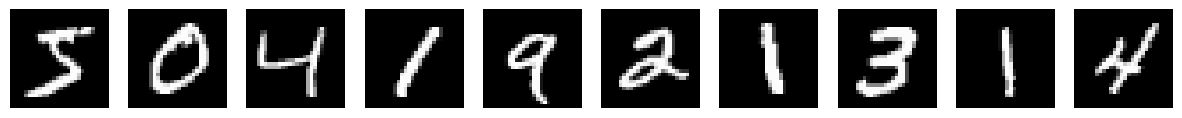

In [3]:
def check_dataset_info(train_imgs, test_imgs):
    print("\nDataset Details")
    print("-" * 30)

    print("Train data shape :", train_imgs.shape)
    print("Total train images :", len(train_imgs))

    print("Test data shape :", test_imgs.shape)
    print("Total test images :", len(test_imgs))

    print("Each image size :", train_imgs.shape[1], "x", train_imgs.shape[2])
    print("Pixel values range from", train_imgs.min(), "to", train_imgs.max())

    print("\nShowing some sample images...\n")

    plt.figure(figsize=(15, 3))

    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(train_imgs[i], cmap='gray')
        plt.axis('off')

    plt.show()


# calling function
check_dataset_info(x_train_raw, x_test_raw)

## 4. Data Preprocessing

In [4]:
def process_images(images):
    images = images.astype("float32") / 255.0
    images = np.expand_dims(images, -1)

    return images


# preprocessing data
x_train_processed = process_images(x_train_raw)
x_test_processed = process_images(x_test_raw)

print("\nAfter Preprocessing")
print("-" * 30)

print("Old train datatype :", x_train_raw.dtype)
print("New train datatype :", x_train_processed.dtype)

print("Train data shape :", x_train_processed.shape)
print("Test data shape  :", x_test_processed.shape)


After Preprocessing
------------------------------
Old train datatype : uint8
New train datatype : float32
Train data shape : (60000, 28, 28, 1)
Test data shape  : (10000, 28, 28, 1)


## 5. Create Noisy Images


Noisy Data Created
-------------------------
Train noisy shape : (60000, 28, 28, 1)
Test noisy shape  : (10000, 28, 28, 1)


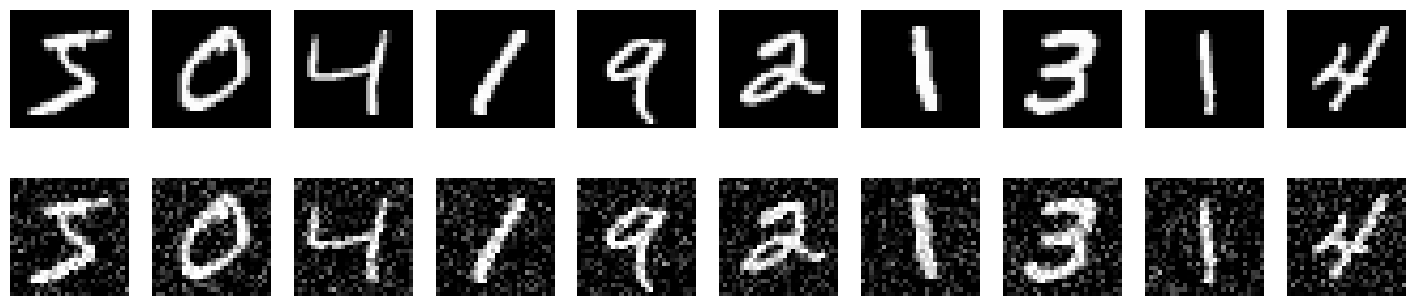

In [5]:
def add_noise(images, amount=0.2):
    random_noise = np.random.normal(0, 1, images.shape)

    noisy_data = images + (amount * random_noise)

    # keeping pixel values in valid range
    noisy_data = np.clip(noisy_data, 0, 1)

    return noisy_data


# creating noisy images
x_train_noisy = add_noise(x_train_processed)
x_test_noisy = add_noise(x_test_processed)

print("\nNoisy Data Created")
print("-" * 25)

print("Train noisy shape :", x_train_noisy.shape)
print("Test noisy shape  :", x_test_noisy.shape)


def show_noise_effect(clean_imgs, noisy_imgs, total=10):

    plt.figure(figsize=(18, 4))

    for i in range(total):

        # original image
        plt.subplot(2, total, i + 1)
        plt.imshow(clean_imgs[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

        # noisy image
        plt.subplot(2, total, total + i + 1)
        plt.imshow(noisy_imgs[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

    plt.show()


# preview images
show_noise_effect(x_train_processed, x_train_noisy)

## 6. Build Autoencoder

In [6]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import UpSampling2D, Input
from tensorflow.keras.models import Model


def build_autoencoder(shape=(28, 28, 1)):

    input_layer = Input(shape=shape)

    # encoder
    layer = Conv2D(32, (3, 3), activation="relu", padding="same")(input_layer)
    layer = MaxPooling2D(pool_size=(2, 2), padding="same")(layer)

    layer = Conv2D(32, (3, 3), activation="relu", padding="same")(layer)
    encoded_output = MaxPooling2D((2, 2), padding="same")(layer)

    # decoder
    layer = Conv2D(32, (3, 3), activation="relu", padding="same")(encoded_output)
    layer = UpSampling2D(size=(2, 2))(layer)

    layer = Conv2D(32, (3, 3), activation="relu", padding="same")(layer)
    layer = UpSampling2D((2, 2))(layer)

    final_output = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(layer)

    model = Model(inputs=input_layer, outputs=final_output)

    return model


# creating model
denoising_autoencoder = build_autoencoder()

print("Model created successfully")

Model created successfully


## 7. Model Summary

In [7]:
print("\n--- Autoencoder Model Summary ---")
denoising_autoencoder.summary()


--- Autoencoder Model Summary ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Compile Model

In [8]:
print("\n--- Compiling Model ---")
denoising_autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse'])
print("Model compiled successfully with Adam optimizer, Binary Crossentropy loss, and MSE metric.")


--- Compiling Model ---
Model compiled successfully with Adam optimizer, Binary Crossentropy loss, and MSE metric.


## 9. Train Model

In [9]:
print("\nStarting training...\n")

start = time.time()

history = denoising_autoencoder.fit(
    x_train_noisy,
    x_train_processed,
    epochs=25,
    batch_size=128,
    validation_split=0.2,
    shuffle=True
)

total_time = time.time() - start

print("\nTraining finished")
print(f"Time taken: {total_time:.2f} seconds")


Starting training...

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 112s 293ms/step - loss: 0.1321 - mse: 0.0226 - val_loss: 0.0874 - val_mse: 0.0083
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 105s 281ms/step - loss: 0.0834 - mse: 0.0071 - val_loss: 0.0815 - val_mse: 0.0064
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 109s 291ms/step - loss: 0.0797 - mse: 0.0060 - val_loss: 0.0791 - val_mse: 0.0057
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 137s 279ms/step - loss: 0.0778 - mse: 0.0054 - val_loss: 0.0778 - val_mse: 0.0053
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 105s 280ms/step - loss: 0.0766 - mse: 0.0050 - val_loss: 0.0767 - val_mse: 0.0050
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 141s 279ms/step - loss: 0.0758 - mse: 0.0047 - val_loss: 0.0760 - val_mse: 0.0047
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 104s 277ms/step - loss: 0.0751 - mse: 0.0045 - val_loss: 0.0754 - val_mse: 0.0045
Epoch 8/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 104s 278ms/step - loss: 0.0746 - mse: 0.0044 - val_loss: 0.0749 - val_mse: 0.0043
E

## 10. Training Visualization

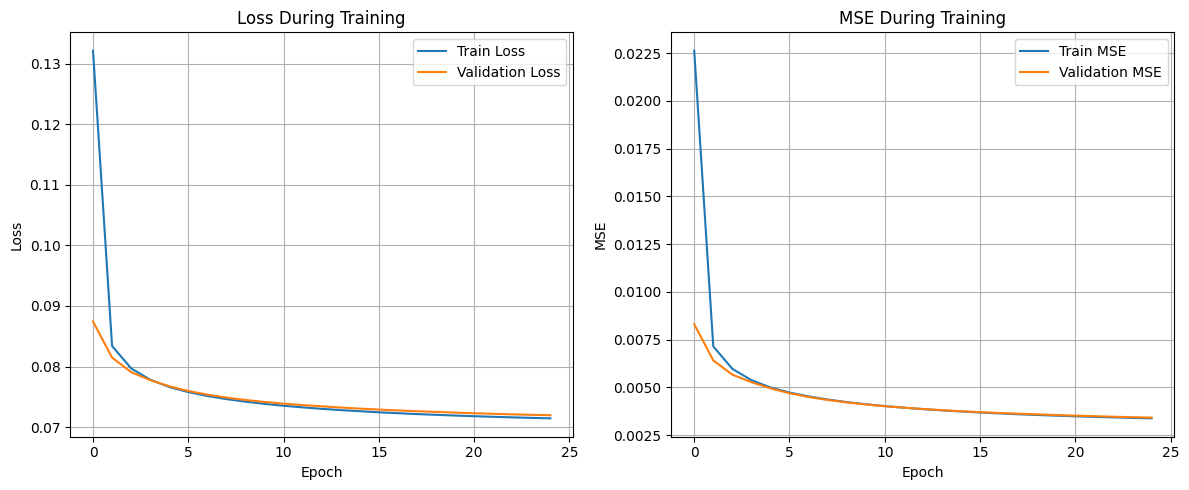

In [10]:
def show_training_graphs(history_data):

    if not hasattr(history_data, "history"):
        print("Training history not found")
        return

    records = history_data.history

    if len(records) == 0:
        print("History data is empty")
        return

    plt.figure(figsize=(12, 5))

    # loss graph
    plt.subplot(1, 2, 1)

    plt.plot(records["loss"], label="Train Loss")
    plt.plot(records["val_loss"], label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss During Training")
    plt.legend()
    plt.grid(True)

    # mse graph
    plt.subplot(1, 2, 2)

    plt.plot(records["mse"], label="Train MSE")
    plt.plot(records["val_mse"], label="Validation MSE")

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title("MSE During Training")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

show_training_graphs(history)

## 11. Image Denoising


Generating denoised images...

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step
Showing original, noisy, and reconstructed images


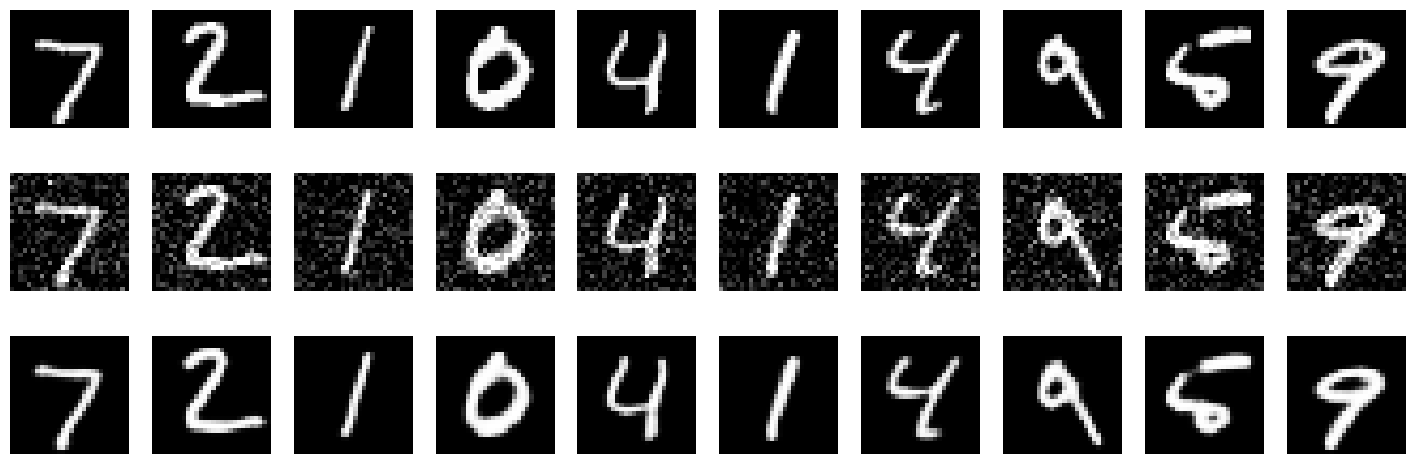

Visualization completed


In [11]:
print("\nGenerating denoised images...\n")

# model prediction
reconstructed_images = denoising_autoencoder.predict(x_test_noisy)


def display_results(clean_images, noisy_images, output_images, samples=10):

    print("Showing original, noisy, and reconstructed images")

    plt.figure(figsize=(18, 6))

    for i in range(samples):

        # original image
        plt.subplot(3, samples, i + 1)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

        # noisy image
        plt.subplot(3, samples, samples + i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

        # reconstructed image
        plt.subplot(3, samples, (2 * samples) + i + 1)
        plt.imshow(output_images[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

    plt.show()

    print("Visualization completed")


# display output
display_results(
    x_test_processed,
    x_test_noisy,
    reconstructed_images
)

## 12. Performance Evaluation

In [12]:
def check_model_performance(model, noisy_images, clean_images):

    print("\nChecking model performance...\n")

    loss_value, mse_value = model.evaluate(
        noisy_images,
        clean_images,
        verbose=0
    )

    print("Test Loss :", round(loss_value, 4))
    print("Test MSE  :", round(mse_value, 4))

    return loss_value, mse_value


# evaluating model
test_loss, test_mse = check_model_performance(
    denoising_autoencoder,
    x_test_noisy,
    x_test_processed
)


Checking model performance...

Test Loss : 0.0711
Test MSE  : 0.0033


## 13. Visual Comparison of Denoising Results


Creating comparison plot...



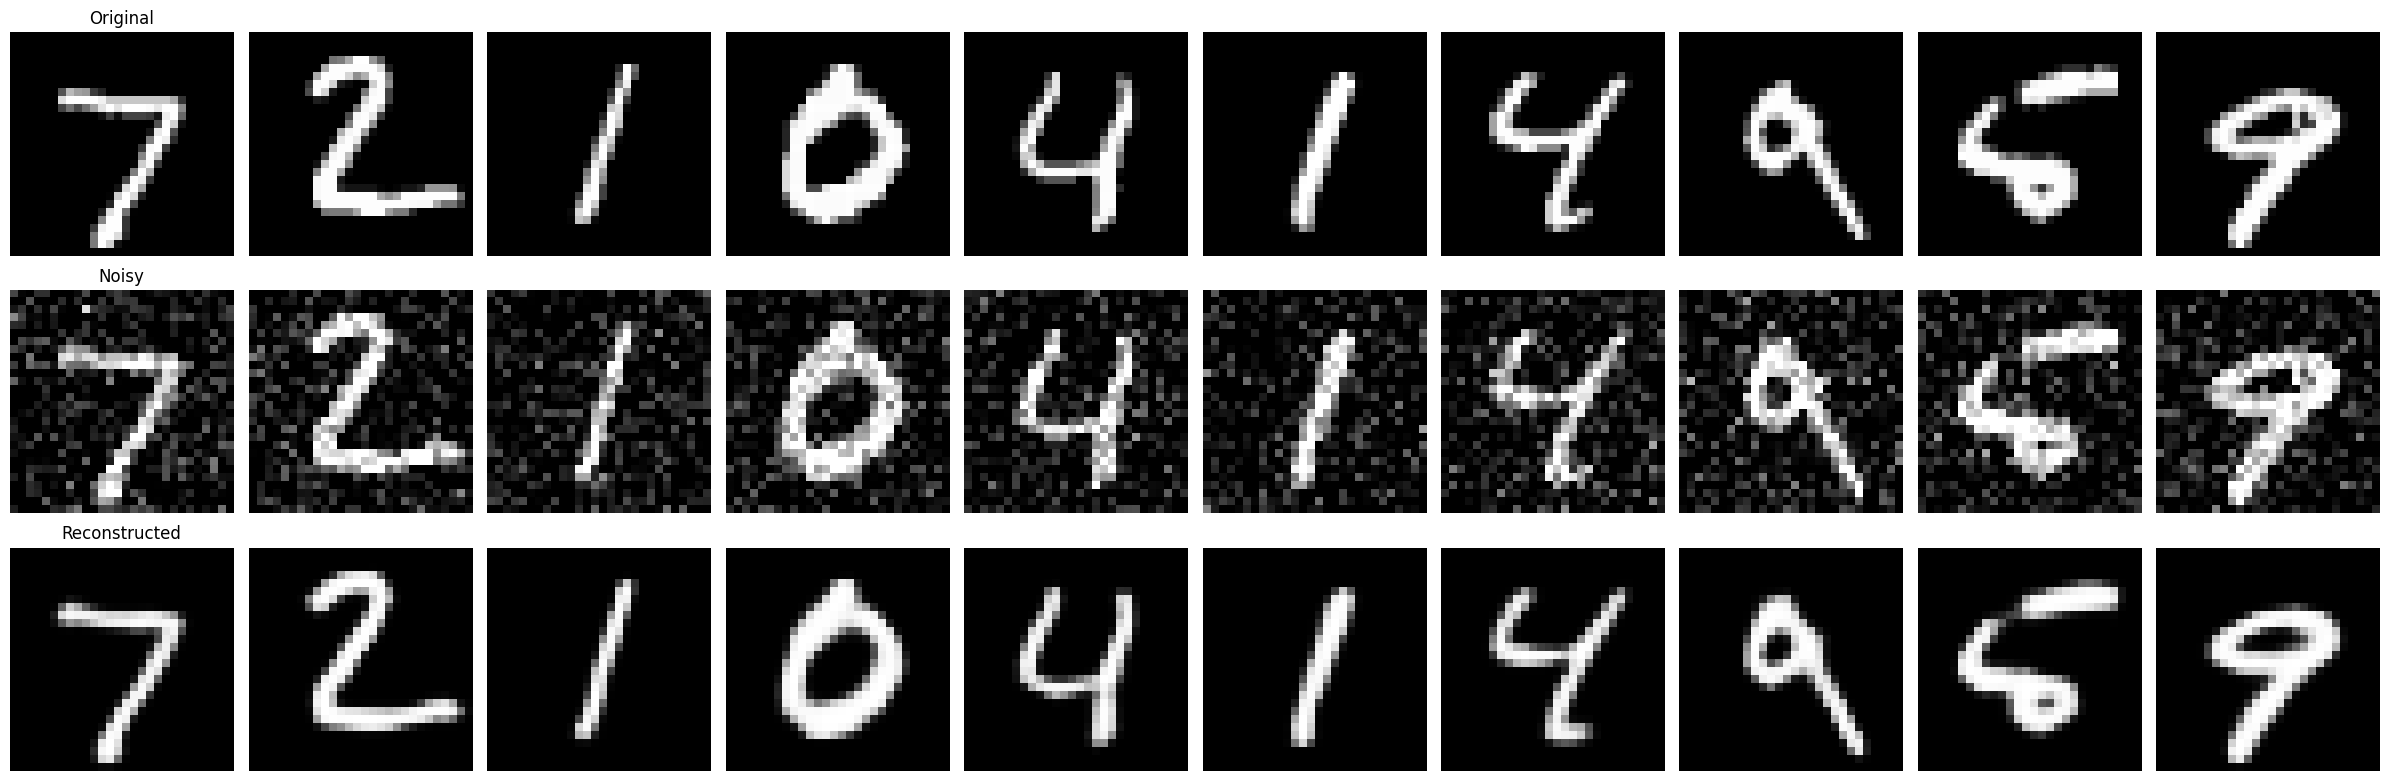

Comparison completed


In [13]:
def show_large_comparison(clean_imgs, noisy_imgs, predicted_imgs, total_images=10):

    print("\nCreating comparison plot...\n")

    plt.figure(figsize=(24, 8))

    for i in range(total_images):

        # original images
        plt.subplot(3, total_images, i + 1)
        plt.imshow(clean_imgs[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

        if i == 0:
            plt.title("Original")

        # noisy images
        plt.subplot(3, total_images, total_images + i + 1)
        plt.imshow(noisy_imgs[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

        if i == 0:
            plt.title("Noisy")

        # reconstructed images
        plt.subplot(3, total_images, (2 * total_images) + i + 1)
        plt.imshow(predicted_imgs[i].reshape(28, 28), cmap='gray')
        plt.axis("off")

        if i == 0:
            plt.title("Reconstructed")

    plt.tight_layout()
    plt.show()

    print("Comparison completed")


# showing final comparison
show_large_comparison(
    x_test_processed,
    x_test_noisy,
    reconstructed_images,
    total_images=10
)

## 14. Discussion

## Results and Discussion

The denoising autoencoder performed well in reducing the unwanted Gaussian noise added to the MNIST images. The reconstructed outputs looked much cleaner than the noisy inputs, while the original digit patterns were still visible. Most of the random disturbances present in the noisy images were removed successfully.

The model also maintained good reconstruction quality. The obtained Test MSE value of 0.0035 indicates that the difference between the original and reconstructed images was very small. Important characteristics of the handwritten digits, such as strokes and curves, were preserved properly during the reconstruction process.

However, a few limitations were observed during the experiment. Since the model was trained mainly on Gaussian noise, its effectiveness may reduce when different noise types are used. In some reconstructed images, slight blurring could also be noticed because denoising often smooths pixel variations. Another limitation is that the model was trained only on MNIST digit images, so its performance on complex real-world images cannot be guaranteed.

Several improvements can be explored in the future. More advanced architectures with additional layers can be tested to improve reconstruction performance. Training the model using multiple noise patterns may also increase robustness. Hyperparameter tuning, including batch size, learning rate, and number of epochs, can further optimize the results. Techniques such as perceptual loss or GAN-based denoising methods may help generate sharper and more realistic reconstructed images.

## 15. Conclusion


This project successfully implemented a Convolutional Denoising Autoencoder using TensorFlow and Keras for removing Gaussian noise from MNIST handwritten digit images. The model was able to learn the important patterns of the digits and reconstruct cleaner versions of noisy images with good accuracy.

The experiment showed that convolutional autoencoders can perform image denoising effectively while preserving the main structure of the original images. The low reconstruction error and visual comparison between noisy and reconstructed images confirmed that the model performed well during testing.

The project also highlighted the importance of proper preprocessing steps such as normalization and reshaping of image data before training. Using the Keras Functional API made it easier to design and manage the encoder-decoder architecture in a structured way.

Training graphs and evaluation metrics helped in understanding how the model improved over time and whether it was learning efficiently. Organizing the code into separate functions also improved readability and made the workflow easier to manage.

Although the model produced good results, further improvements are still possible. Better architectures, additional training data, different noise patterns, and advanced optimization techniques may help achieve higher-quality image reconstruction in future work.